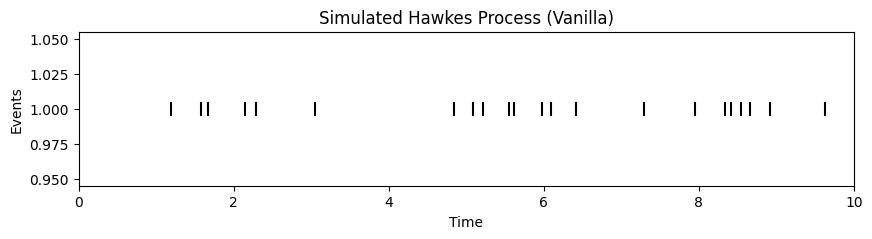

Generated event times: [ 1.18671434  1.57069658  1.66839421  2.14836768  2.28569597  3.04927529
  4.83626834  5.09143481  5.22009806  5.54670308  5.61685928  5.97789552
  6.09072044  6.41897095  7.29767642  7.95362612  8.34210509  8.41840348
  8.53994112  8.65900882  8.92065543  9.63028986 10.4607277 ]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set parameters for a basic Hawkes Process
mu = 0.5  # Base intensity (spontaneous event rate)
alpha = 0.8  # Excitation factor (impact of past events)
beta = 1.5  # Decay rate (how fast influence of past events fades)
T = 10  # Total time for simulation

# Initialize event times list
event_times = []
current_time = 0

# Simulate the process
while current_time < T:
    # Compute intensity
    lambda_t = mu + sum(alpha * np.exp(-beta * (current_time - t)) for t in event_times)
    
    # Generate next event time using Poisson thinning
    inter_arrival_time = np.random.exponential(1 / lambda_t)
    current_time += inter_arrival_time
    
    # Accept event with probability proportional to lambda_t
    if np.random.rand() < lambda_t / (mu + alpha):
        event_times.append(current_time)

# Convert event times to a numpy array
event_times = np.array(event_times)

# Plot the Hawkes Process realization
plt.figure(figsize=(10, 2))
plt.scatter(event_times, np.ones_like(event_times), marker='|', color='black', s=100)
plt.xlabel("Time")
plt.ylabel("Events")
plt.title("Simulated Hawkes Process (Vanilla)")
plt.xlim(0, T)
plt.show()

# Print generated event times
print("Generated event times:", event_times)


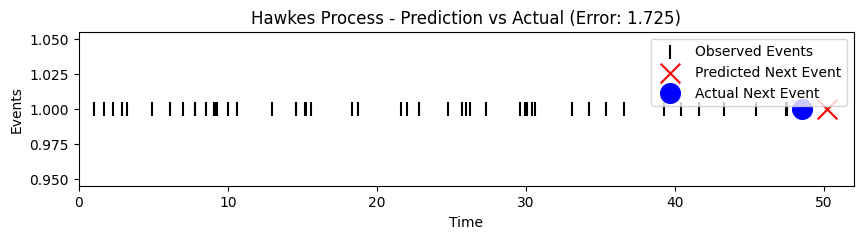

Predicted next event time: 50.22055355080629
Actual next event time: 48.49549260809972
Prediction error: 1.7250609427065697


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Define Hawkes Process parameters
mu = 0.5  # Base intensity (spontaneous event rate)
alpha = 0.8  # Excitation factor (impact of past events)
beta = 1.5  # Decay rate (how fast influence of past events fades)
T = 50  # Total simulation time

# Generate synthetic event times as observed data
np.random.seed(42)
event_times = np.sort(np.random.uniform(0, T, size=50))  # Assume we have observed 10 events

# Separate training and test set
train_events = event_times[:-1]  # Use first 9 events for prediction
actual_next_event = event_times[-1]  # Last event as ground truth

# Function to predict the next event based on Hawkes intensity function
def predict_next_event(event_times, mu, alpha, beta):
    current_time = event_times[-1]  # Start prediction from the last observed event
    lambda_t = mu + sum(alpha * np.exp(-beta * (current_time - t)) for t in event_times)
    
    # Generate the next event time using an exponential inter-arrival time based on intensity
    inter_arrival_time = np.random.exponential(1 / lambda_t)
    next_event_time = current_time + inter_arrival_time
    
    return next_event_time

# Predict the next event
predicted_event_time = predict_next_event(train_events, mu, alpha, beta)

# Compute error
error = abs(predicted_event_time - actual_next_event)

# Plot observed, actual, and predicted event times
plt.figure(figsize=(10, 2))
plt.scatter(event_times, np.ones_like(event_times), marker='|', color='black', s=100, label="Observed Events")
plt.scatter(predicted_event_time, 1, marker='x', color='red', s=200, label="Predicted Next Event")
plt.scatter(actual_next_event, 1, marker='o', color='blue', s=200, label="Actual Next Event")
plt.xlabel("Time")
plt.ylabel("Events")
plt.title(f"Hawkes Process - Prediction vs Actual (Error: {error:.3f})")
plt.xlim(0, T + 2)
plt.legend()
plt.show()

# Output predicted and actual event times
print("Predicted next event time:", predicted_event_time)
print("Actual next event time:", actual_next_event)
print("Prediction error:", error)


Epoch 0, Loss: 78.3769
Epoch 50, Loss: 0.2475
Epoch 100, Loss: 0.1275
Epoch 150, Loss: 0.1261
Epoch 200, Loss: 0.1247
Epoch 250, Loss: 0.1231
Epoch 300, Loss: 0.1213
Epoch 350, Loss: 0.1193
Epoch 400, Loss: 0.1173
Epoch 450, Loss: 0.1150
Predicted next event time: 10.40064525604248
Actual next event time: 10.480957576905142


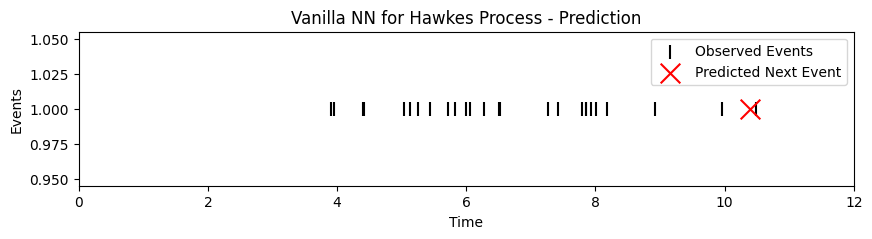

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---- Step 1: Generate Hawkes Process Events ----

# Hawkes process parameters
mu = 0.5    # Base intensity
alpha = 0.8  # Excitation factor
beta = 1.5   # Decay rate
T = 10       # Total simulation time

# Generate event times using the Hawkes process
def simulate_hawkes(mu, alpha, beta, T, seed=42):
    np.random.seed(seed)
    event_times = []
    current_time = 0

    while current_time < T:
        # Compute intensity
        lambda_t = mu + sum(alpha * np.exp(-beta * (current_time - t)) for t in event_times)
        
        # Sample inter-arrival time from exponential distribution
        inter_arrival_time = np.random.exponential(1 / lambda_t)
        current_time += inter_arrival_time

        # Poisson thinning: Accept event with probability proportional to lambda_t
        if np.random.rand() < lambda_t / (mu + alpha):
            event_times.append(current_time)

    return np.array(event_times)

# Generate a dataset
event_times = simulate_hawkes(mu, alpha, beta, T)

# ---- Step 2: Prepare Training Data ----

window_size = 5  # Use the last 5 events to predict the next
X_train = []
y_train = []

for i in range(len(event_times) - window_size):
    X_train.append(event_times[i:i + window_size])
    y_train.append(event_times[i + window_size])

X_train = np.array(X_train)
y_train = np.array(y_train)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # Reshape for MLP

# ---- Step 3: Define Neural Network ----

class HawkesMLP(nn.Module):
    def __init__(self, input_size=5, hidden_size=16):
        super(HawkesMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)  # Output next event time

# Create model
model = HawkesMLP()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ---- Step 4: Train the Neural Network ----
epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# ---- Step 5: Predict the Next Event ----

last_events = torch.tensor(event_times[-window_size:], dtype=torch.float32).view(1, -1)
predicted_next_event = model(last_events).item()

print(f"Predicted next event time: {predicted_next_event}")
print(f"Actual next event time: {event_times[-1]}")

# ---- Step 6: Plot the Result ----
plt.figure(figsize=(10, 2))
plt.scatter(event_times, np.ones_like(event_times), marker='|', color='black', s=100, label="Observed Events")
plt.scatter(predicted_next_event, 1, marker='x', color='red', s=200, label="Predicted Next Event")
plt.xlabel("Time")
plt.ylabel("Events")
plt.title("Vanilla NN for Hawkes Process - Prediction")
plt.legend()
plt.xlim(0, T + 2)
plt.show()


In [33]:
# Re-import necessary libraries since execution state was reset
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Function to simulate Hawkes Process given parameters
def simulate_hawkes(mu, alpha, beta, T, seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    event_times = []
    current_time = 0

    while current_time < T:
        lambda_t = mu + sum(alpha * np.exp(-beta * (current_time - t)) for t in event_times)
        inter_arrival_time = np.random.exponential(1 / lambda_t)
        current_time += inter_arrival_time

        if np.random.rand() < lambda_t / (mu + alpha):
            event_times.append(current_time)

    return np.array(event_times)

# Generate multiple datasets with different parameters
num_samples = 100  # Increased sample size
T = 10  # Time window

train_X = []
train_Y = []

for _ in range(num_samples):
    # Sample random Hawkes parameters within a range
    true_mu = np.random.uniform(0.1, 1.0)
    true_alpha = np.random.uniform(0.5, 2.0)
    true_beta = np.random.uniform(0.5, 2.0)
    
    # Simulate Hawkes process
    event_times = simulate_hawkes(true_mu, true_alpha, true_beta, T)
    
    # Use last 10 events as input (zero-padding if needed)
    window_size = 10
    event_input = np.pad(event_times[-window_size:], (0, max(0, window_size - len(event_times))), 'constant')
    
    train_X.append(event_input)
    train_Y.append([true_mu, true_alpha, true_beta])

# Convert to NumPy arrays
train_X = np.array(train_X)
train_Y = np.array(train_Y)

# Convert to PyTorch tensors
train_X_tensor = torch.tensor(train_X, dtype=torch.float32)
train_Y_tensor = torch.tensor(train_Y, dtype=torch.float32)

# Define Neural Network
class HawkesParamNN(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=3):
        super(HawkesParamNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return torch.relu(self.fc2(x))  # Ensure positive outputs for Hawkes parameters

# Initialize model
model = HawkesParamNN()

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the Neural Network with Timer
epochs = 500
loss_history = []

start_time = time.time()  # Start timing

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(train_X_tensor)
    loss = criterion(predictions, train_Y_tensor)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())  # Store loss value

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

end_time = time.time()  # End timing
training_time = end_time - start_time

# Generate a new test sequence
test_mu, test_alpha, test_beta = 0.6, 1.2, 1.0
test_events = simulate_hawkes(test_mu, test_alpha, test_beta, T)

# Prepare input (last 10 events)
test_input = np.pad(test_events[-window_size:], (0, max(0, window_size - len(test_events))), 'constant')
test_input_tensor = torch.tensor(test_input, dtype=torch.float32).view(1, -1)

# Predict parameters
predicted_params = model(test_input_tensor).detach().numpy().flatten()

# Print results
print("\nTraining Time:", training_time, "seconds")
print("\nTrue Parameters:")
print(f"  mu: {test_mu:.3f}, alpha: {test_alpha:.3f}, beta: {test_beta:.3f}")
print("Predicted Parameters:")
print(f"  mu: {predicted_params[0]:.3f}, alpha: {predicted_params[1]:.3f}, beta: {predicted_params[2]:.3f}")

# Plot Loss History
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


KeyboardInterrupt: 

In [ ]:
import numpy as np
import torch

def simulate_hawkes(mu, alpha, beta, T, seed=None):
    """
    Simulates a 1D Hawkes Process with exponential decay kernel.
    
    Args:
        mu (float): Base intensity.
        alpha (float): Excitation factor.
        beta (float): Decay rate.
        T (float): Total simulation time.
        seed (int, optional): Random seed for reproducibility.
    
    Returns:
        np.array: List of event times.
    """
    if seed is not None:
        np.random.seed(seed)
    
    event_times = []
    current_time = 0

    while current_time < T:
        lambda_t = mu + sum(alpha * np.exp(-beta * (current_time - t)) for t in event_times)
        inter_arrival_time = np.random.exponential(1 / lambda_t)
        current_time += inter_arrival_time

        if np.random.rand() < lambda_t / (mu + alpha):  # Poisson thinning
            event_times.append(current_time)

    return np.array(event_times)


def generate_hawkes_dataset(num_samples=1000, T=10, window_size=5, seed=42):
    """
    Generates a synthetic dataset of event sequences using the Hawkes Process.
    
    Args:
        num_samples (int): Number of sequences to generate.
        T (float): Total time for each sequence.
        window_size (int): Number of past events to use as input.
        seed (int): Random seed for reproducibility.
    
    Returns:
        tuple: (X_train, y_train) - Inputs and targets for training.
    """
    np.random.seed(seed)
    
    X_data, y_data = [], []

    for _ in range(num_samples):
        # Randomly sample Hawkes parameters
        mu = np.random.uniform(0.1, 1.0)   # Base intensity
        alpha = np.random.uniform(0.5, 2.0)  # Excitation factor
        beta = np.random.uniform(0.5, 2.0)   # Decay rate

        # Generate event times
        event_times = simulate_hawkes(mu, alpha, beta, T)
        
        # Ensure enough events for windowing
        if len(event_times) < window_size + 1:
            continue  # Skip sequences that are too short

        # Convert event sequences into training samples
        for i in range(len(event_times) - window_size):
            X_data.append(event_times[i:i + window_size])
            y_data.append(event_times[i + window_size])  # Next event time

    # Convert to NumPy arrays
    X_data = np.array(X_data)
    y_data = np.array(y_data)

    # Convert to PyTorch tensors
    X_train_tensor = torch.tensor(X_data, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_data, dtype=torch.float32).view(-1, 1)  # Reshape for NN

    return X_train_tensor, y_train_tensor


# Example usage:
X_train, y_train = generate_hawkes_dataset(num_samples=5000)

print("Shape of X_train:", X_train.shape)  # (num_samples, window_size)
print("Shape of y_train:", y_train.shape)  # (num_samples, 1)
